# Bio-PM IRB Analysis (Standard vs Adv vs Alt)


In [1]:
import sys, os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA
import umap
warnings.filterwarnings('ignore')
%matplotlib inline

BIOPM_ROOT = "CS690TR"
sys.path.insert(0, BIOPM_ROOT)

STD_LEGACY = "features/biopm_features_legacy_schema.npz"
ADV_LEGACY = "features/biopm_features_legacy_schema_adv.npz"
ALT_LEGACY = "features/biopm_features_legacy_schema_alt.npz"
ADV_WIN    = "features/biopm_features_adv.npz"
ALT_WIN    = "features/biopm_features_alt.npz"
RESULTS    = "outputs"
os.makedirs(f"{RESULTS}/figures", exist_ok=True)
os.makedirs(f"{RESULTS}/metrics", exist_ok=True)
os.makedirs(f"{RESULTS}/splits", exist_ok=True)


## 1) Dataset Overview


Visits: 223
Subjects: 61
ARAT range: (np.float64(0.0), np.float64(57.0))
FMA range : (np.float64(3.0), np.float64(66.0))
Healthy visits convention (ARAT=57,FMA=66): 8
Healthy subjects: 8
Spearman ARAT~FMA: SignificanceResult(statistic=np.float64(0.9557208072313761), pvalue=np.float64(2.2039973243998045e-119))


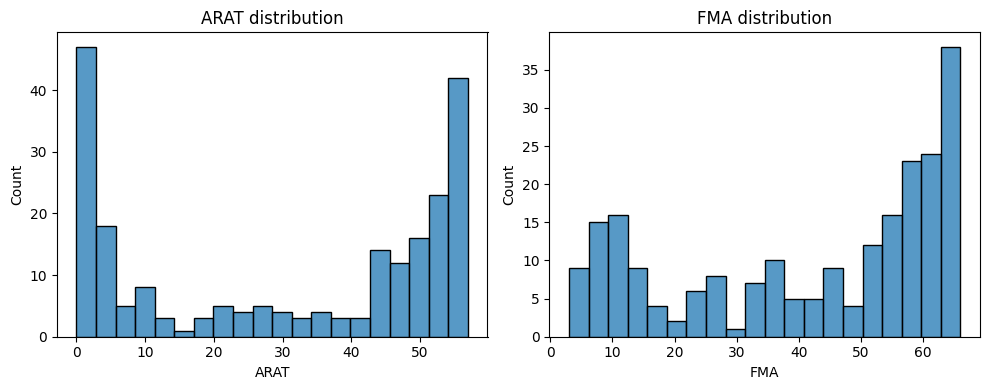

In [2]:
clin = np.load('data/clinical_scores.npz', allow_pickle=True)['clinical_scores'].item()
rows=[]
for (s,w),rec in clin.items():
    rows.append({'subject':int(s),'week':int(w),'ARAT':float(rec.ARAT),'FMA':float(rec.FMA)})
clin_df=pd.DataFrame(rows)
print('Visits:',len(clin_df))
print('Subjects:',clin_df.subject.nunique())
print('ARAT range:',(clin_df.ARAT.min(),clin_df.ARAT.max()))
print('FMA range :',(clin_df.FMA.min(),clin_df.FMA.max()))
healthy=(clin_df.ARAT==57)&(clin_df.FMA==66)
print('Healthy visits convention (ARAT=57,FMA=66):',int(healthy.sum()))
print('Healthy subjects:',clin_df.loc[healthy,'subject'].nunique())
print('Spearman ARAT~FMA:',spearmanr(clin_df.ARAT,clin_df.FMA))

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(clin_df.ARAT,bins=20,ax=ax[0],kde=False)
ax[0].set_title('ARAT distribution')
sns.histplot(clin_df.FMA,bins=20,ax=ax[1],kde=False)
ax[1].set_title('FMA distribution')
plt.tight_layout()
plt.show()


## 2) Load Features (Standard + Adv + Alt)


In [3]:
def load_legacy(path):
    d = np.load(path, allow_pickle=True)
    return {
        'X': np.ascontiguousarray(d['features'], dtype=np.float32),
        'Xe': np.ascontiguousarray(d['features_even'], dtype=np.float32),
        'Xo': np.ascontiguousarray(d['features_odd'], dtype=np.float32),
        'arat': d['arat'].astype(float),
        'fma': d['fma'].astype(float),
        'pids': d['pids'].astype(int),
        'labels': d['labels'].astype(int),
        'subjects': d['subjects'].astype(int),
        'weeks': d['weeks'].astype(int),
    }

def quality(name, X):
    print(f"{name}: shape={X.shape}, NaN={np.isnan(X).sum()}, zero_rows={(np.abs(X)<1e-8).all(axis=1).sum()}")
    print(f"  acc mean [0:64]   abs={np.abs(X[:,0:64]).mean():.5f}")
    print(f"  acc std  [64:128] abs={np.abs(X[:,64:128]).mean():.5f}")
    print(f"  grav     [128:]   abs={np.abs(X[:,128:]).mean():.5f}")

std = load_legacy(STD_LEGACY)
adv = load_legacy(ADV_LEGACY)
alt = load_legacy(ALT_LEGACY)
quality('Standard', std['X'])
quality('Adv', adv['X'])
quality('Alt', alt['X'])


Standard: shape=(198, 1028), NaN=0, zero_rows=0
  acc mean [0:64]   abs=0.72586
  acc std  [64:128] abs=0.25406
  grav     [128:]   abs=0.00196
Adv: shape=(198, 1028), NaN=0, zero_rows=0
  acc mean [0:64]   abs=0.75860
  acc std  [64:128] abs=0.26038
  grav     [128:]   abs=0.00196
Alt: shape=(198, 1028), NaN=0, zero_rows=0
  acc mean [0:64]   abs=0.76232
  acc std  [64:128] abs=0.26981
  grav     [128:]   abs=0.00283


## 3) LOSO Regression Helpers


In [4]:
def loso_regression(X, y_scores, pids, alpha=1.0, label=''):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for tr, te in logo.split(X, y_scores, groups=pids):
        X_tr, y_tr = X[tr], y_scores[tr]
        X_te, y_te = X[te], y_scores[te]
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        reg = Ridge(alpha=alpha)
        reg.fit(X_tr_s, y_tr)
        y_pred.extend(reg.predict(X_te_s).tolist())
        y_true.extend(y_te.tolist())
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    ss_res=((y_true-y_pred)**2).sum(); ss_tot=((y_true-y_true.mean())**2).sum()
    r2=1-ss_res/ss_tot
    rmse=np.sqrt(((y_true-y_pred)**2).mean())
    sr,sp=spearmanr(y_true,y_pred)
    print(f"{label}: R²={r2:.3f} RMSE={rmse:.2f} Spearman ρ={sr:.3f} (p={sp:.3g})")
    return {'r2':r2,'rmse':rmse,'spearman_r':sr,'spearman_p':sp,'y_true':y_true,'y_pred':y_pred}

def loso_regression_pca(X, y_scores, pids, n_components=50, alpha=1.0, label=''):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for tr, te in logo.split(X, y_scores, groups=pids):
        X_tr, y_tr = X[tr], y_scores[tr]
        X_te, y_te = X[te], y_scores[te]
        sc=StandardScaler(); X_tr_s=sc.fit_transform(X_tr); X_te_s=sc.transform(X_te)
        pca=PCA(n_components=min(n_components, X_tr_s.shape[0]-1, X_tr_s.shape[1]))
        X_tr_p=pca.fit_transform(X_tr_s); X_te_p=pca.transform(X_te_s)
        reg=Ridge(alpha=alpha); reg.fit(X_tr_p,y_tr)
        y_pred.extend(reg.predict(X_te_p).tolist()); y_true.extend(y_te.tolist())
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    ss_res=((y_true-y_pred)**2).sum(); ss_tot=((y_true-y_true.mean())**2).sum()
    r2=1-ss_res/ss_tot; rmse=np.sqrt(((y_true-y_pred)**2).mean()); sr,sp=spearmanr(y_true,y_pred)
    print(f"{label} [PCA]: R²={r2:.3f} RMSE={rmse:.2f} Spearman ρ={sr:.3f} (p={sp:.3g})")
    return {'r2':r2,'rmse':rmse,'spearman_r':sr,'spearman_p':sp,'y_true':y_true,'y_pred':y_pred}

def plot_pred(ax, y_true, y_pred, title):
    ax.scatter(y_true,y_pred,s=30,alpha=0.8)
    lo=min(y_true.min(),y_pred.min()); hi=max(y_true.max(),y_pred.max())
    ax.plot([lo,hi],[lo,hi],'r--',lw=1)
    ax.set_title(title); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')


## 4) Standard Pipeline Regression


Standard -> ARAT: R²=0.482 RMSE=16.59 Spearman ρ=0.723 (p=2.29e-33)
Standard -> FMA: R²=0.332 RMSE=17.47 Spearman ρ=0.680 (p=3.41e-28)
Standard -> ARAT [PCA]: R²=0.459 RMSE=16.94 Spearman ρ=0.715 (p=2.46e-32)
Standard -> FMA [PCA]: R²=0.320 RMSE=17.62 Spearman ρ=0.678 (p=5.9e-28)


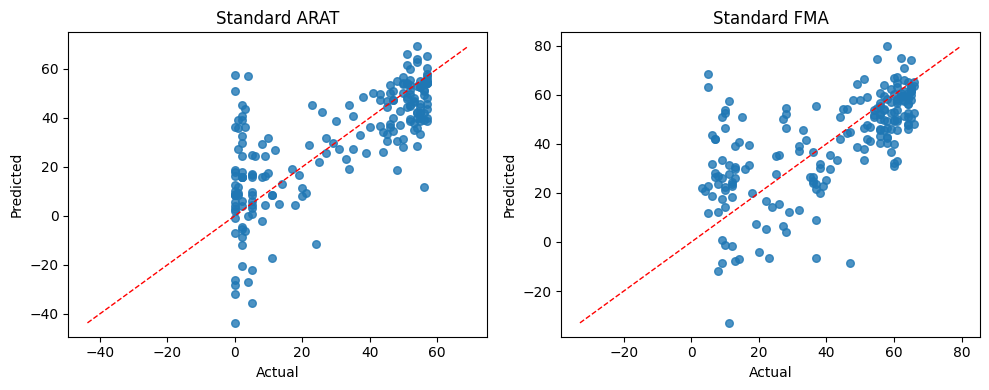

In [5]:
res_std_arat = loso_regression(std['X'], std['arat'], std['pids'], label='Standard -> ARAT')
res_std_fma  = loso_regression(std['X'], std['fma'],  std['pids'], label='Standard -> FMA')
res_std_arat_pca = loso_regression_pca(std['X'], std['arat'], std['pids'], label='Standard -> ARAT')
res_std_fma_pca  = loso_regression_pca(std['X'], std['fma'],  std['pids'], label='Standard -> FMA')

fig,ax=plt.subplots(1,2,figsize=(10,4))
plot_pred(ax[0],res_std_arat['y_true'],res_std_arat['y_pred'],'Standard ARAT')
plot_pred(ax[1],res_std_fma['y_true'],res_std_fma['y_pred'],'Standard FMA')
plt.tight_layout(); plt.savefig('outputs/figures/regression_standard.png',dpi=150); plt.show()

pd.DataFrame([
    {'target':'ARAT','pipeline':'Standard','r2':res_std_arat['r2'],'rmse':res_std_arat['rmse'],'spearman_r':res_std_arat['spearman_r']},
    {'target':'FMA','pipeline':'Standard','r2':res_std_fma['r2'],'rmse':res_std_fma['rmse'],'spearman_r':res_std_fma['spearman_r']},
]).to_csv('outputs/metrics/regression_standard.csv',index=False)


## 5) Adv + Alt Pipeline Regression


Adv -> ARAT: R²=0.492 RMSE=16.43 Spearman ρ=0.722 (p=3.58e-33)
Adv -> FMA: R²=0.410 RMSE=16.41 Spearman ρ=0.692 (p=1.58e-29)
Adv -> ARAT [PCA]: R²=0.512 RMSE=16.10 Spearman ρ=0.734 (p=1.04e-34)
Adv -> FMA [PCA]: R²=0.366 RMSE=17.01 Spearman ρ=0.686 (p=6.33e-29)
Alt -> ARAT: R²=0.447 RMSE=17.13 Spearman ρ=0.728 (p=6.52e-34)
Alt -> FMA: R²=0.353 RMSE=17.18 Spearman ρ=0.673 (p=1.75e-27)
Alt -> ARAT [PCA]: R²=0.490 RMSE=16.45 Spearman ρ=0.734 (p=1.03e-34)
Alt -> FMA [PCA]: R²=0.408 RMSE=16.45 Spearman ρ=0.707 (p=2.27e-31)


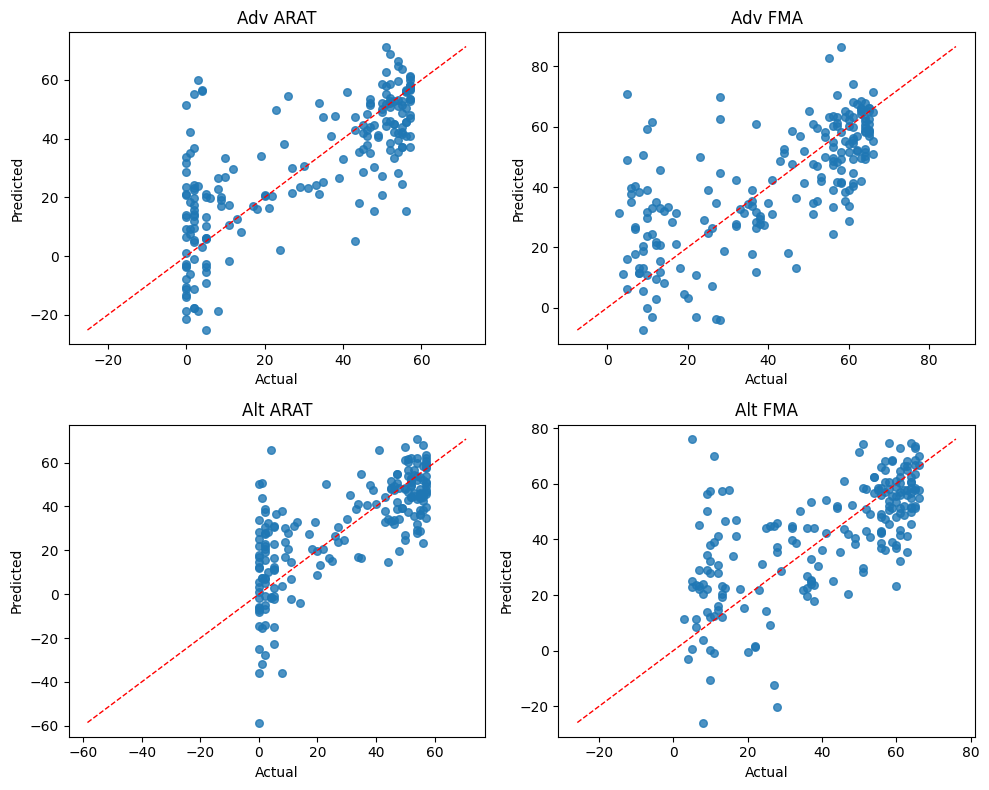

In [6]:
res_adv_arat = loso_regression(adv['X'], adv['arat'], adv['pids'], label='Adv -> ARAT')
res_adv_fma  = loso_regression(adv['X'], adv['fma'],  adv['pids'], label='Adv -> FMA')
res_adv_arat_pca = loso_regression_pca(adv['X'], adv['arat'], adv['pids'], label='Adv -> ARAT')
res_adv_fma_pca  = loso_regression_pca(adv['X'], adv['fma'],  adv['pids'], label='Adv -> FMA')

res_alt_arat = loso_regression(alt['X'], alt['arat'], alt['pids'], label='Alt -> ARAT')
res_alt_fma  = loso_regression(alt['X'], alt['fma'],  alt['pids'], label='Alt -> FMA')
res_alt_arat_pca = loso_regression_pca(alt['X'], alt['arat'], alt['pids'], label='Alt -> ARAT')
res_alt_fma_pca  = loso_regression_pca(alt['X'], alt['fma'],  alt['pids'], label='Alt -> FMA')

fig,ax=plt.subplots(2,2,figsize=(10,8))
plot_pred(ax[0,0],res_adv_arat['y_true'],res_adv_arat['y_pred'],'Adv ARAT')
plot_pred(ax[0,1],res_adv_fma['y_true'],res_adv_fma['y_pred'],'Adv FMA')
plot_pred(ax[1,0],res_alt_arat['y_true'],res_alt_arat['y_pred'],'Alt ARAT')
plot_pred(ax[1,1],res_alt_fma['y_true'],res_alt_fma['y_pred'],'Alt FMA')
plt.tight_layout(); plt.savefig('outputs/figures/regression_adv_alt.png',dpi=150); plt.show()

pd.DataFrame([
    {'target':'ARAT','pipeline':'Adv','r2':res_adv_arat['r2'],'rmse':res_adv_arat['rmse'],'spearman_r':res_adv_arat['spearman_r']},
    {'target':'FMA','pipeline':'Adv','r2':res_adv_fma['r2'],'rmse':res_adv_fma['rmse'],'spearman_r':res_adv_fma['spearman_r']},
]).to_csv('outputs/metrics/regression_adv.csv',index=False)

pd.DataFrame([
    {'target':'ARAT','pipeline':'Alt','r2':res_alt_arat['r2'],'rmse':res_alt_arat['rmse'],'spearman_r':res_alt_arat['spearman_r']},
    {'target':'FMA','pipeline':'Alt','r2':res_alt_fma['r2'],'rmse':res_alt_fma['rmse'],'spearman_r':res_alt_fma['spearman_r']},
]).to_csv('outputs/metrics/regression_alt.csv',index=False)


## 6) Standard vs Adv vs Alt Comparison


,target,pipeline,r2,rmse,spearman_r
0,ARAT,Standard,0.481676,16.589550,0.723416
1,ARAT,Adv,0.491660,16.428997,0.721908
2,ARAT,Alt,0.447282,17.131109,0.727576
3,FMA,Standard,0.331714,17.470185,0.679742
4,FMA,Adv,0.410321,16.410580,0.691793
5,FMA,Alt,0.353419,17.184141,0.673095


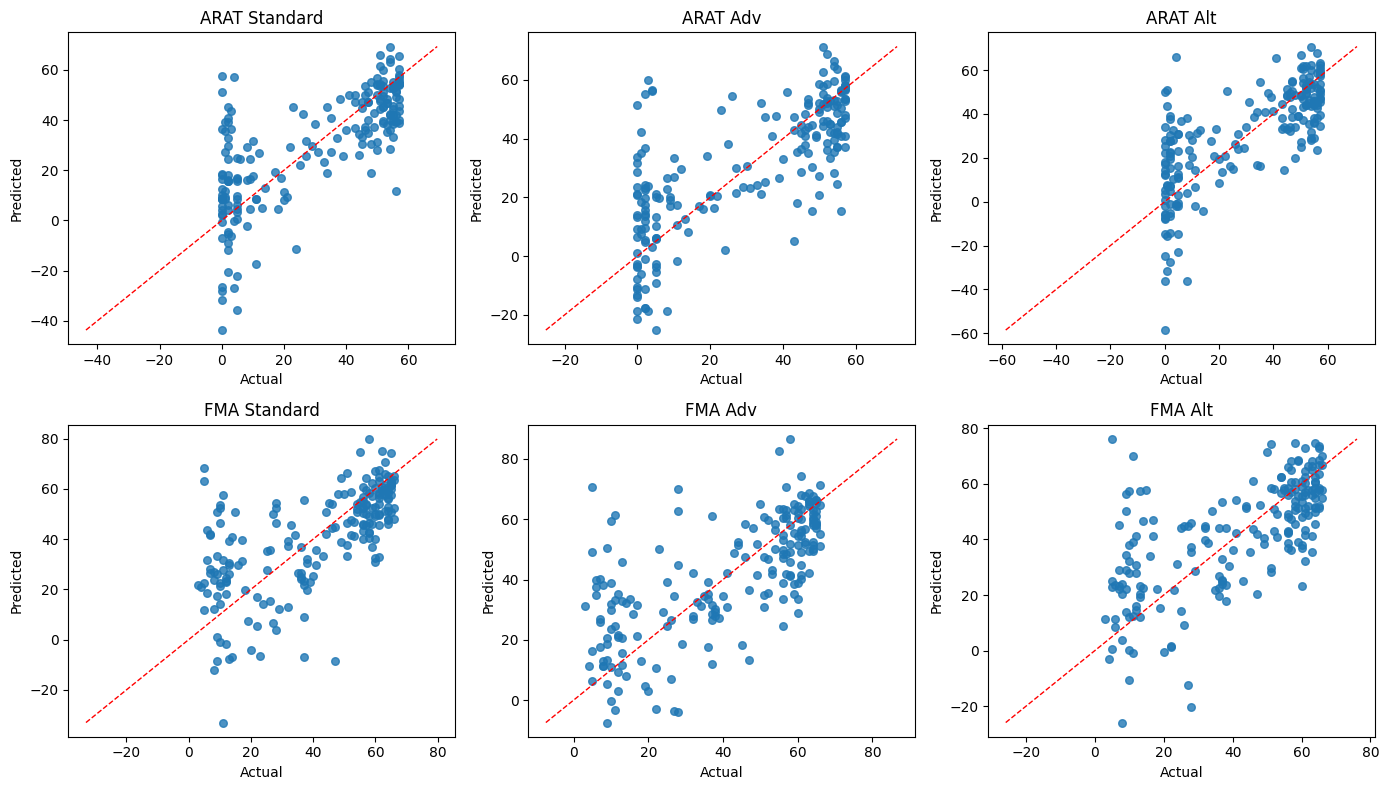

In [7]:
comp = pd.DataFrame([
    {'target':'ARAT','pipeline':'Standard','r2':res_std_arat['r2'],'rmse':res_std_arat['rmse'],'spearman_r':res_std_arat['spearman_r']},
    {'target':'ARAT','pipeline':'Adv','r2':res_adv_arat['r2'],'rmse':res_adv_arat['rmse'],'spearman_r':res_adv_arat['spearman_r']},
    {'target':'ARAT','pipeline':'Alt','r2':res_alt_arat['r2'],'rmse':res_alt_arat['rmse'],'spearman_r':res_alt_arat['spearman_r']},
    {'target':'FMA','pipeline':'Standard','r2':res_std_fma['r2'],'rmse':res_std_fma['rmse'],'spearman_r':res_std_fma['spearman_r']},
    {'target':'FMA','pipeline':'Adv','r2':res_adv_fma['r2'],'rmse':res_adv_fma['rmse'],'spearman_r':res_adv_fma['spearman_r']},
    {'target':'FMA','pipeline':'Alt','r2':res_alt_fma['r2'],'rmse':res_alt_fma['rmse'],'spearman_r':res_alt_fma['spearman_r']},
])
comp.to_csv('outputs/metrics/regression_comparison.csv',index=False)
display(comp)

fig,ax=plt.subplots(2,3,figsize=(14,8))
plot_pred(ax[0,0],res_std_arat['y_true'],res_std_arat['y_pred'],'ARAT Standard')
plot_pred(ax[0,1],res_adv_arat['y_true'],res_adv_arat['y_pred'],'ARAT Adv')
plot_pred(ax[0,2],res_alt_arat['y_true'],res_alt_arat['y_pred'],'ARAT Alt')
plot_pred(ax[1,0],res_std_fma['y_true'],res_std_fma['y_pred'],'FMA Standard')
plot_pred(ax[1,1],res_adv_fma['y_true'],res_adv_fma['y_pred'],'FMA Adv')
plot_pred(ax[1,2],res_alt_fma['y_true'],res_alt_fma['y_pred'],'FMA Alt')
plt.tight_layout(); plt.savefig('outputs/figures/regression_comparison.png',dpi=150); plt.show()


## 7) Aggregation Experiments (Adv)


adv:full_1028 -> ARAT: R²=0.492 RMSE=16.43 Spearman ρ=0.722 (p=3.58e-33)
adv:full_1028 -> FMA: R²=0.410 RMSE=16.41 Spearman ρ=0.692 (p=1.58e-29)
adv:acc_128 -> ARAT: R²=0.562 RMSE=15.26 Spearman ρ=0.753 (p=1.82e-37)
adv:acc_128 -> FMA: R²=0.483 RMSE=15.36 Spearman ρ=0.720 (p=5.61e-33)
adv:acc_meanpool_64 -> ARAT: R²=0.524 RMSE=15.89 Spearman ρ=0.754 (p=1.22e-37)
adv:acc_meanpool_64 -> FMA: R²=0.397 RMSE=16.60 Spearman ρ=0.735 (p=7.55e-35)
adv:acc_stdpool_64 -> ARAT: R²=0.401 RMSE=17.83 Spearman ρ=0.708 (p=1.95e-31)
adv:acc_stdpool_64 -> FMA: R²=0.292 RMSE=17.98 Spearman ρ=0.674 (p=1.43e-27)
adv:gravity_900 -> ARAT: R²=-0.173 RMSE=24.96 Spearman ρ=-0.050 (p=0.486)
adv:gravity_900 -> FMA: R²=-0.204 RMSE=23.45 Spearman ρ=-0.031 (p=0.664)
alt:full_1028 -> ARAT: R²=0.447 RMSE=17.13 Spearman ρ=0.728 (p=6.52e-34)
alt:full_1028 -> FMA: R²=0.353 RMSE=17.18 Spearman ρ=0.673 (p=1.75e-27)
alt:acc_128 -> ARAT: R²=0.560 RMSE=15.28 Spearman ρ=0.730 (p=3.4e-34)
alt:acc_128 -> FMA: R²=0.468 RMSE=15.59 

,pipeline,experiment,mode,target,r2,rmse,spearman_r
0,adv,dim_group,full_1028,ARAT,0.491660,16.428997,0.721908
1,adv,dim_group,full_1028,FMA,0.410321,16.410580,0.691793
2,adv,dim_group,acc_128,ARAT,0.561611,15.256809,0.752945
3,adv,dim_group,acc_128,FMA,0.483282,15.361827,0.720393
4,adv,dim_group,acc_meanpool_64,ARAT,0.524251,15.893620,0.754105
5,adv,dim_group,acc_meanpool_64,FMA,0.396532,16.601350,0.734549
6,adv,dim_group,acc_stdpool_64,ARAT,0.401049,17.833213,0.708039
7,adv,dim_group,acc_stdpool_64,FMA,0.291829,17.983958,0.673938
8,adv,dim_group,gravity_900,ARAT,-0.172964,24.956062,-0.049797
9,adv,dim_group,gravity_900,FMA,-0.204467,23.453825,-0.031061


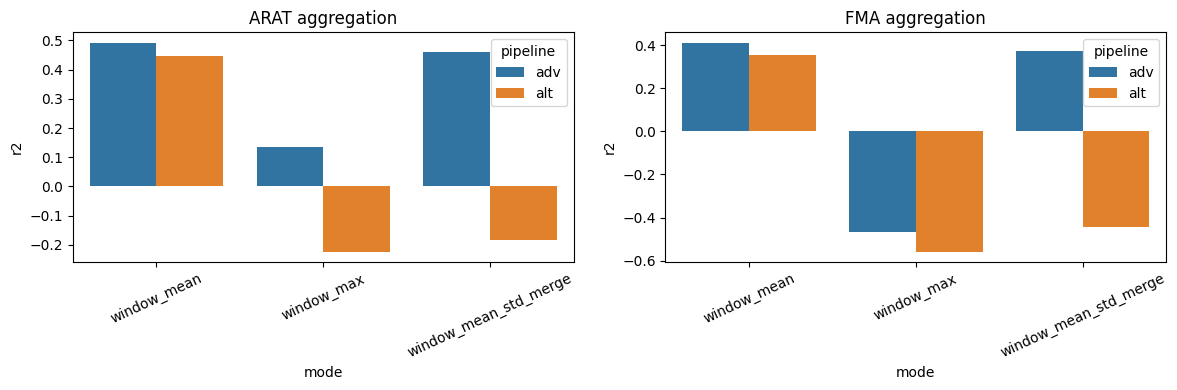

In [8]:
dim_groups={
    'full_1028':(0,1028),
    'acc_128':(0,128),
    'acc_meanpool_64':(0,64),
    'acc_stdpool_64':(64,128),
    'gravity_900':(128,1028),
}
rows=[]
for pipe_name, pipe in [('adv',adv),('alt',alt)]:
    for name,(a,b) in dim_groups.items():
        rA=loso_regression(pipe['X'][:,a:b],pipe['arat'],pipe['pids'],label=f'{pipe_name}:{name} -> ARAT')
        rF=loso_regression(pipe['X'][:,a:b],pipe['fma'],pipe['pids'],label=f'{pipe_name}:{name} -> FMA')
        rows += [
            {'pipeline':pipe_name,'experiment':'dim_group','mode':name,'target':'ARAT','r2':rA['r2'],'rmse':rA['rmse'],'spearman_r':rA['spearman_r']},
            {'pipeline':pipe_name,'experiment':'dim_group','mode':name,'target':'FMA','r2':rF['r2'],'rmse':rF['rmse'],'spearman_r':rF['spearman_r']},
        ]

adv_win=np.load(ADV_WIN,allow_pickle=True)
alt_win=np.load(ALT_WIN,allow_pickle=True)

def aggregate_windows(features_win, subj, week, mode='mean'):
    groups=defaultdict(list)
    for i,(s,w) in enumerate(zip(subj,week)):
        groups[(s,w)].append(i)
    out=[]
    for key in sorted(groups.keys()):
        idx=np.array(groups[key]); blk=features_win[idx]
        if mode=='mean': out.append(blk.mean(0))
        elif mode=='max': out.append(blk.max(0))
        elif mode=='mean_std_merge': out.append(np.concatenate([blk.mean(0),blk.std(0)]))
    return np.array(out,dtype=np.float32)

for pipe_name, win_d, legacy in [('adv',adv_win,adv),('alt',alt_win,alt)]:
    Xw=win_d['features'].astype(np.float32); sw=win_d['subj'].astype(int); ww=win_d['week'].astype(int)
    Xm=aggregate_windows(Xw,sw,ww,'mean')
    Xx=aggregate_windows(Xw,sw,ww,'max')
    Xms=aggregate_windows(Xw,sw,ww,'mean_std_merge')
    for mode,X in [('window_mean',Xm),('window_max',Xx),('window_mean_std_merge',Xms)]:
        rA=loso_regression(X,legacy['arat'],legacy['pids'],label=f'{pipe_name}:{mode} -> ARAT')
        rF=loso_regression(X,legacy['fma'],legacy['pids'],label=f'{pipe_name}:{mode} -> FMA')
        rows += [
            {'pipeline':pipe_name,'experiment':'aggregation','mode':mode,'target':'ARAT','r2':rA['r2'],'rmse':rA['rmse'],'spearman_r':rA['spearman_r']},
            {'pipeline':pipe_name,'experiment':'aggregation','mode':mode,'target':'FMA','r2':rF['r2'],'rmse':rF['rmse'],'spearman_r':rF['spearman_r']},
        ]

abl=pd.DataFrame(rows)
abl.to_csv('outputs/metrics/aggregation_ablation.csv',index=False)
display(abl.head(20))

fig,ax=plt.subplots(1,2,figsize=(12,4))
tmp=abl[(abl.experiment=='aggregation') & (abl.target=='ARAT')]
sns.barplot(data=tmp,x='mode',y='r2',hue='pipeline',ax=ax[0]); ax[0].tick_params(axis='x',rotation=25); ax[0].set_title('ARAT aggregation')
tmp=abl[(abl.experiment=='aggregation') & (abl.target=='FMA')]
sns.barplot(data=tmp,x='mode',y='r2',hue='pipeline',ax=ax[1]); ax[1].tick_params(axis='x',rotation=25); ax[1].set_title('FMA aggregation')
plt.tight_layout(); plt.savefig('outputs/figures/aggregation_ablation.png',dpi=150); plt.show()


## 8) Spearman Correlation Profiles


Top-10 |rho| ARAT (Adv): [(np.int64(117), np.float64(0.7252008483105552)), (np.int64(92), np.float64(0.7212132033896781)), (np.int64(10), np.float64(0.717074569971797)), (np.int64(119), np.float64(0.7120749149710001)), (np.int64(107), np.float64(0.7098046674160463)), (np.int64(123), np.float64(0.7059354903928188)), (np.int64(94), np.float64(0.7039617997319807)), (np.int64(125), np.float64(0.7013330512841404)), (np.int64(56), np.float64(-0.6948653235124731)), (np.int64(25), np.float64(-0.6933778932419867))]
Top-10 |rho| FMA  (Adv): [(np.int64(92), np.float64(0.7101334550553097)), (np.int64(10), np.float64(0.7074971013754675)), (np.int64(117), np.float64(0.7043039349501027)), (np.int64(94), np.float64(0.7019838818437586)), (np.int64(107), np.float64(0.7009081505534505)), (np.int64(125), np.float64(0.6998393794224613)), (np.int64(119), np.float64(0.6972308663798952)), (np.int64(123), np.float64(0.6908940279954342)), (np.int64(56), np.float64(-0.688152498574771)), (np.int64(17), np.float64

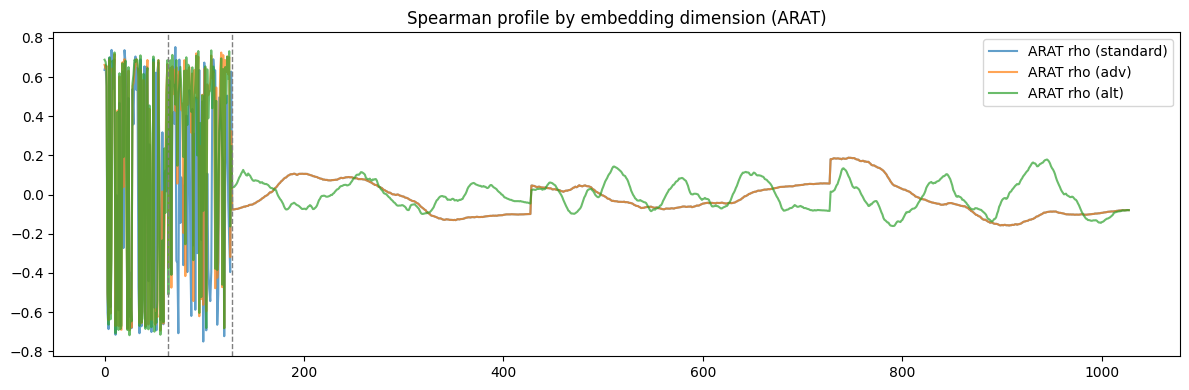

In [9]:
def spearman_profile(X, arat, fma):
    sA=np.zeros(X.shape[1]); sF=np.zeros(X.shape[1])
    for d in range(X.shape[1]):
        sA[d],_=spearmanr(X[:,d],arat)
        sF[d],_=spearmanr(X[:,d],fma)
    return sA,sF

sA_adv,sF_adv=spearman_profile(adv['X'],adv['arat'],adv['fma'])
sA_std,sF_std=spearman_profile(std['X'],std['arat'],std['fma'])
sA_alt,sF_alt=spearman_profile(alt['X'],alt['arat'],alt['fma'])

pd.DataFrame({'dim':np.arange(1028),'rho_arat':sA_adv,'rho_fma':sF_adv}).to_csv('outputs/metrics/spearman_adv.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'rho_arat':sA_std,'rho_fma':sF_std}).to_csv('outputs/metrics/spearman_standard.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'rho_arat':sA_alt,'rho_fma':sF_alt}).to_csv('outputs/metrics/spearman_alt.csv',index=False)

def topk(rho,k=10):
    idx=np.argsort(np.abs(rho))[::-1][:k]
    return list(zip(idx,rho[idx]))

print('Top-10 |rho| ARAT (Adv):',topk(sA_adv,10))
print('Top-10 |rho| FMA  (Adv):',topk(sF_adv,10))
print('Top-10 |rho| ARAT (Alt):',topk(sA_alt,10))
print('Top-10 |rho| FMA  (Alt):',topk(sF_alt,10))

fig,ax=plt.subplots(figsize=(12,4))
ax.plot(sA_std,label='ARAT rho (standard)',alpha=0.7)
ax.plot(sA_adv,label='ARAT rho (adv)',alpha=0.7)
ax.plot(sA_alt,label='ARAT rho (alt)',alpha=0.7)
ax.axvline(64,color='gray',ls='--',lw=1); ax.axvline(128,color='gray',ls='--',lw=1)
ax.set_title('Spearman profile by embedding dimension (ARAT)')
ax.legend(); plt.tight_layout(); plt.savefig('outputs/figures/spearman_profile.png',dpi=150); plt.show()


## 9) ICC Reliability (Even vs Odd)


Adv ICC >0.75: 127 /1028
Alt ICC >0.75: 125 /1028


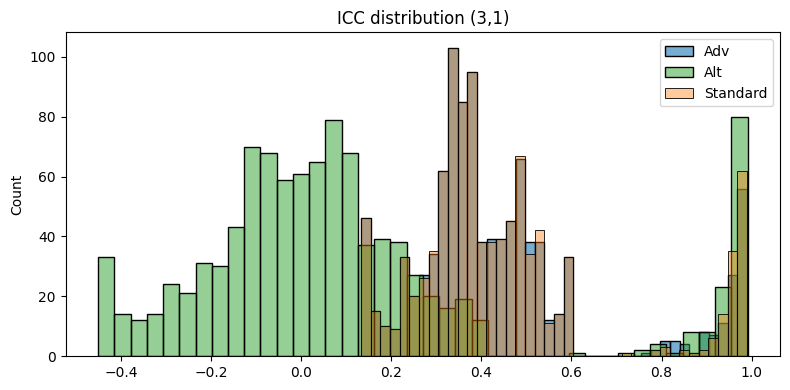

In [10]:
def icc_3_1(x,y):
    n=len(x)
    m=(x+y)/2.0
    SS_between=2*n*m.var()
    SS_within=((x-m)**2 + (y-m)**2).sum()
    MS_between=SS_between/(n-1)
    MS_within=SS_within/n
    return (MS_between-MS_within)/(MS_between+MS_within)

def icc_profile(Xe,Xo):
    out=np.zeros(Xe.shape[1])
    for d in range(Xe.shape[1]):
        out[d]=icc_3_1(Xe[:,d],Xo[:,d])
    return out

icc_adv=icc_profile(adv['Xe'],adv['Xo'])
icc_std=icc_profile(std['Xe'],std['Xo'])
icc_alt=icc_profile(alt['Xe'],alt['Xo'])

pd.DataFrame({'dim':np.arange(1028),'icc':icc_adv}).to_csv('outputs/metrics/icc_adv.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'icc':icc_std}).to_csv('outputs/metrics/icc_standard.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'icc':icc_alt}).to_csv('outputs/metrics/icc_alt.csv',index=False)

print('Adv ICC >0.75:',int((icc_adv>0.75).sum()),'/1028')
print('Alt ICC >0.75:',int((icc_alt>0.75).sum()),'/1028')

fig,ax=plt.subplots(figsize=(8,4))
sns.histplot(icc_adv,bins=40,ax=ax,color='tab:blue',alpha=0.6,label='Adv')
sns.histplot(icc_alt,bins=40,ax=ax,color='tab:green',alpha=0.5,label='Alt')
sns.histplot(icc_std,bins=40,ax=ax,color='tab:orange',alpha=0.4,label='Standard')
ax.legend(); ax.set_title('ICC distribution (3,1)');
plt.tight_layout(); plt.savefig('outputs/figures/icc_distribution.png',dpi=150); plt.show()


## 10) Summary + Full Metrics Export


In [11]:
summary_rows=[
    {'section':'dataset','metric':'subjects_total','value':int(clin_df.subject.nunique())},
    {'section':'dataset','metric':'visits_total','value':int(len(clin_df))},
    {'section':'dataset','metric':'healthy_visits','value':int(((clin_df.ARAT==57)&(clin_df.FMA==66)).sum())},
    {'section':'regression','metric':'ARAT_R2_standard','value':res_std_arat['r2']},
    {'section':'regression','metric':'ARAT_R2_adv','value':res_adv_arat['r2']},
    {'section':'regression','metric':'ARAT_R2_alt','value':res_alt_arat['r2']},
    {'section':'regression','metric':'FMA_R2_standard','value':res_std_fma['r2']},
    {'section':'regression','metric':'FMA_R2_adv','value':res_adv_fma['r2']},
    {'section':'regression','metric':'FMA_R2_alt','value':res_alt_fma['r2']},
    {'section':'regression','metric':'ARAT_spearman_standard','value':res_std_arat['spearman_r']},
    {'section':'regression','metric':'ARAT_spearman_adv','value':res_adv_arat['spearman_r']},
    {'section':'regression','metric':'ARAT_spearman_alt','value':res_alt_arat['spearman_r']},
    {'section':'regression','metric':'FMA_spearman_standard','value':res_std_fma['spearman_r']},
    {'section':'regression','metric':'FMA_spearman_adv','value':res_adv_fma['spearman_r']},
    {'section':'regression','metric':'FMA_spearman_alt','value':res_alt_fma['spearman_r']},
    {'section':'icc_adv','metric':'count_gt_0_75','value':int((icc_adv>0.75).sum())},
    {'section':'icc_alt','metric':'count_gt_0_75','value':int((icc_alt>0.75).sum())},
    {'section':'icc_standard','metric':'count_gt_0_75','value':int((icc_std>0.75).sum())},
]
summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv('outputs/metrics/full_summary.csv',index=False)
display(summary_df)


,section,metric,value
0,dataset,subjects_total,61.000000
1,dataset,visits_total,223.000000
2,dataset,healthy_visits,8.000000
3,regression,ARAT_R2_standard,0.481676
4,regression,ARAT_R2_adv,0.491660
5,regression,ARAT_R2_alt,0.447282
6,regression,FMA_R2_standard,0.331714
7,regression,FMA_R2_adv,0.410321
8,regression,FMA_R2_alt,0.353419
9,regression,ARAT_spearman_standard,0.723416
